In [1]:
import os
import scipy.io
import numpy as np
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [2]:
name_format = "Linear_results5"
print("Run:", name_format)

Run: Linear_results5


Function to generate file names based on the input format

In [3]:
def generate_filename(base_name, extension):
    return f"{name_format}_{base_name}.{extension}"

Load and preprocess the data

In [4]:
print("Loading data...", flush=True)

Loading data...


Define the path to the .mat file

In [5]:
file_path = os.path.join('MATLAB_DATA', 'results5.mat')

Load the .mat file

In [6]:
mat_contents = scipy.io.loadmat(file_path)

Access the 'results' variable

In [7]:
results = mat_contents['results']

Define a fixed length for resampling

In [8]:
fixed_length = 1200  # Adjust based on the average length of your data

Initialize lists to hold the data

In [9]:
X_data = []
I_data = []
B_MAG_data = []
EDC_MAG_data = []

Function to resample and smooth data

In [10]:
def resample_and_smooth(X, I, new_length):
    # Define new X as evenly spaced values between 6562.3 and 6563.3
    X_new = np.linspace(6562.3, 6563.3, num=new_length)
    
    # Interpolate the I values over the new X values
    f = interp1d(X, I, kind='cubic', fill_value="extrapolate")
    I_new = f(X_new)
    
    return X_new, I_new

Iterate through the results

In [11]:
for result in results[0]:
    B_MAG = result['B_MAG'][0]
    EDC_MAG = result['EDC_MAG'][0]
    X = result['X'][0]
    I = result['I'][0]
    
    # Scale the X values by 10^10
    X = X * 10**10

    # Resample X and smooth I
    X_resampled, I_resampled = resample_and_smooth(X, I, fixed_length)
    
    # Store the data in lists
    X_data.append(X_resampled)
    I_data.append(I_resampled)
    B_MAG_data.append(B_MAG)
    EDC_MAG_data.append(EDC_MAG)

Convert lists to numpy arrays

In [12]:
X_data = np.array(X_data)
I_data = np.array(I_data)
B_MAG_data = np.array(B_MAG_data)
EDC_MAG_data = np.array(EDC_MAG_data)

Preprocess the data

In [13]:
means = np.mean(I_data, axis=0)
stds = np.std(I_data, axis=0)

Find the first and last column with std >= 0.01

In [14]:
start_index = 0
end_index = I_data.shape[1] - 1

In [15]:
for i in range(I_data.shape[1]):
    if stds[i] >= 0.01:
        start_index = i
        break

In [16]:
for i in range(I_data.shape[1] - 1, -1, -1):
    if stds[i] >= 0.01:
        end_index = i
        break

Filter the data based on the calculated start and end indices

In [17]:
X_resampled = X_data[0]
I_data_filtered = I_data[:, start_index:end_index + 1]
X_resampled_filtered = X_resampled[start_index:end_index + 1]
means_filtered = means[start_index:end_index + 1]
stds_filtered = stds[start_index:end_index + 1]

Normalize the filtered data

In [18]:
normalized_I = (I_data_filtered - means_filtered) / stds_filtered

Combine B and E components to create the output data (target)

In [19]:
target_data = np.column_stack((B_MAG_data, EDC_MAG_data))

Split the data into training and test sets

In [20]:
I_train, I_test, target_train, target_test = train_test_split(normalized_I, target_data, test_size=0.2, random_state=42)

Separate B and E components

In [21]:
B_train = target_train[:, :3]
E_train = target_train[:, 3:]
B_test = target_test[:, :3]
E_test = target_test[:, 3:]

Initialize scalers for B and E components

In [22]:
scaler_B = MinMaxScaler()
scaler_E = MinMaxScaler()

Fit the scaler on the training data and transform both training and test data

In [23]:
B_train_scaled = scaler_B.fit_transform(B_train)
B_test_scaled = scaler_B.transform(B_test)
E_train_scaled = scaler_E.fit_transform(E_train)
E_test_scaled = scaler_E.transform(E_test)

Combine the scaled B and E components for the train and test sets

In [24]:
target_train_scaled = np.column_stack((B_train_scaled, E_train_scaled))
target_test_scaled = np.column_stack((B_test_scaled, E_test_scaled))

Train the linear regression model

In [25]:
print("Training linear regression model...", flush=True)
linear_model = LinearRegression()
linear_model.fit(I_train, target_train_scaled)

Training linear regression model...


LinearRegression()

In [26]:
train_subset_indices = np.random.choice(len(I_train), size=1000, replace=False)
train_input_data_subset = I_train[train_subset_indices]
train_target_data_subset = target_train_scaled[train_subset_indices]
# Make predictions on the train set
predictions_train = linear_model.predict(train_input_data_subset)

In [27]:
mae_train = mean_absolute_error(train_target_data_subset, predictions_train)
rmse_train = np.sqrt(mean_squared_error(train_target_data_subset, predictions_train))
r2_train = r2_score(train_target_data_subset, predictions_train)

In [28]:
def normalized_root_mean_squared_error(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return rmse / (y_true.max() - y_true.min())

In [29]:
nrmse_train = normalized_root_mean_squared_error(train_target_data_subset, predictions_train)

In [30]:
print(f'NRMSE (Train): {nrmse_train:.2f}')
print(f'Mean Absolute Error (MAE, Train): {mae_train}')
print(f'Root Mean Squared Error (RMSE, Train): {rmse_train}')
print(f'R^2 Score (Train): {r2_train}')

NRMSE (Train): 0.20
Mean Absolute Error (MAE, Train): 0.1611319147916212
Root Mean Squared Error (RMSE, Train): 0.20468533152146834
R^2 Score (Train): 0.5067346234140534


Plot the true vs. predicted B and E values for the training set

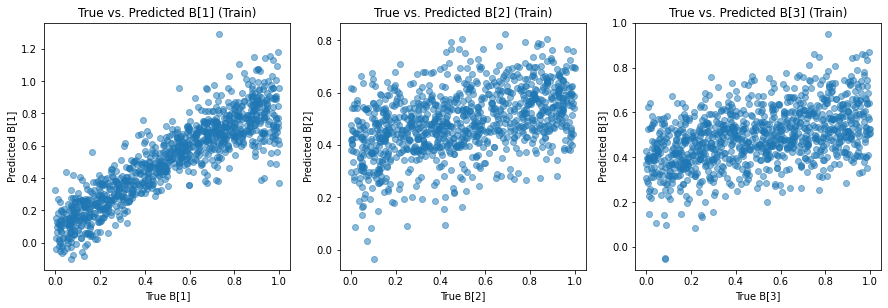

In [31]:
plt.figure(figsize=(15, 10))
for i in range(3):
    plt.subplot(2, 3, i+1)
    plt.scatter(train_target_data_subset[:, i], predictions_train[:, i], alpha=0.5)
    plt.xlabel(f'True B[{i+1}]')
    plt.ylabel(f'Predicted B[{i+1}]')
    plt.title(f'True vs. Predicted B[{i+1}] (Train)')

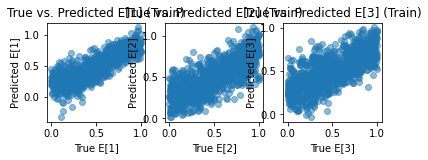

In [32]:
for i in range(3):
    plt.subplot(2, 3, i+4)
    plt.scatter(train_target_data_subset[:, i+3], predictions_train[:, i+3], alpha=0.5)
    plt.xlabel(f'True E[{i+1}]')
    plt.ylabel(f'Predicted E[{i+1}]')
    plt.title(f'True vs. Predicted E[{i+1}] (Train)')

In [33]:
plt.tight_layout()
figure_train_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_train", "png"))
plt.savefig(figure_train_file, dpi=300, facecolor='white')
plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>

Test set evaluation

In[79]:

Make predictions on the test set

In [34]:
predictions_test = linear_model.predict(I_test)
mae_test = mean_absolute_error(target_test_scaled, predictions_test)
rmse_test = np.sqrt(mean_squared_error(target_test_scaled, predictions_test))
r2_test = r2_score(target_test_scaled, predictions_test)
nrmse_test = normalized_root_mean_squared_error(target_test_scaled, predictions_test)

In[80]:

In [35]:
print(f'NRMSE (Test): {nrmse_test:.2f}')
print(f'Mean Absolute Error (MAE, Test): {mae_test}')
print(f'Root Mean Squared Error (RMSE, Test): {rmse_test}')
print(f'R^2 Score (Test): {r2_test}')

NRMSE (Test): 0.24
Mean Absolute Error (MAE, Test): 0.18589510467166112
Root Mean Squared Error (RMSE, Test): 0.23798914650760375
R^2 Score (Test): 0.322066135630795


In[81]:

In [36]:
metrics_test_file = os.path.join("/home/botingl/machine learning", generate_filename("evaluation_metrics_test", "txt"))
with open(metrics_test_file, "w") as f:
    f.write(f"Mean Absolute Error (MAE): {mae_test}\n")
    f.write(f"Root Mean Squared Error (RMSE): {rmse_test}\n")
    f.write(f"R^2 Score: {r2_test}\n")
    f.write(f"Normalized RMSE (NRMSE): {nrmse_test}\n")

In[82]:

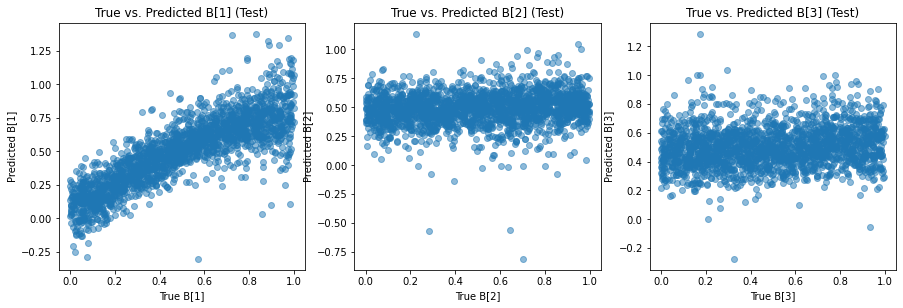

In [37]:
plt.figure(figsize=(15, 10))
for i in range(3):
    plt.subplot(2, 3, i+1)
    plt.scatter(target_test_scaled[:, i], predictions_test[:, i], alpha=0.5)
    plt.xlabel(f'True B[{i+1}]')
    plt.ylabel(f'Predicted B[{i+1}]')
    plt.title(f'True vs. Predicted B[{i+1}] (Test)')

In[83]:

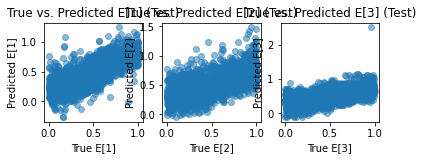

In [38]:
for i in range(3):
    plt.subplot(2, 3, i+4)
    plt.scatter(target_test_scaled[:, i+3], predictions_test[:, i+3], alpha=0.5)
    plt.xlabel(f'True E[{i+1}]')
    plt.ylabel(f'Predicted E[{i+1}]')
    plt.title(f'True vs. Predicted E[{i+1}] (Test)')

In[84]:

In [39]:
plt.tight_layout()
figure_test_file = os.path.join("/home/botingl/machine learning", generate_filename("true_vs_predictions_test", "png"))
plt.savefig(figure_test_file, dpi=300, facecolor='white')
plt.show()
plt.close()

<Figure size 432x288 with 0 Axes>